# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin 2197525
- Lara Fogarolo 2199475
- Francesco Peron 2185610

# Exercise 4: data visualization and clustering

## 1. "eps" and "minPts" in DBSCAN algorithm for clustering

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.ticker import NullFormatter
plt.rcParams['font.size'] = 12

# manifold.TSNE
from sklearn import manifold  #, datasets
from time import time

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

In [2]:
fname,fnamey="x_12d.dat","y_12d.dat" 
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)
N=len(data) #number of data points
D=len(data[0]) #number of features
print("N=",N,"  L=D=",D)
x=data

N= 600   L=D= 12


t-SNE with perplexity=2: 1.6 sec
t-SNE with perplexity=4: 1.5 sec
t-SNE with perplexity=8: 1.5 sec
t-SNE with perplexity=16: 1.6 sec
t-SNE with perplexity=32: 2 sec


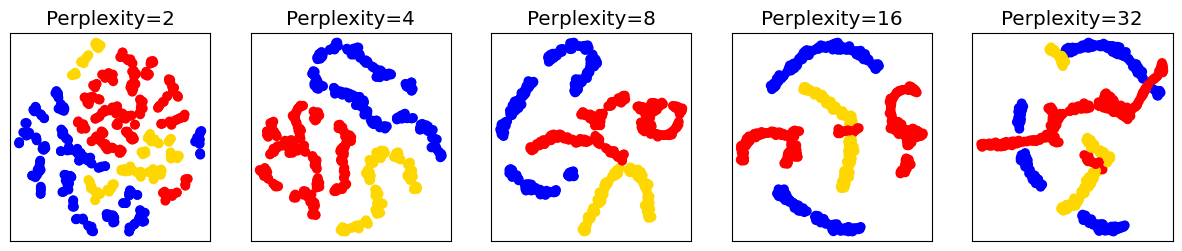

In [3]:
np.random.seed(0)
n_samples = N # number of data points to consider
n_components = 2 # dimension of the embedded space
perplexities = [2, 4, 8, 16, 32]
Np = len(perplexities)
mycmap = ListedColormap(["blue","red","gold" ])

(fig, subplots) = plt.subplots(1,Np , figsize=(3*Np, 2.7))

X_all = [None]
for i, perplexity in enumerate(perplexities):
    ax = subplots[i]

    t0 = time()
    tsne = manifold.TSNE(n_components=n_components, init='random',
                         random_state=0, perplexity=perplexity, learning_rate='auto')
    Y = tsne.fit_transform(data) # apply t-SNE to the data
    t1 = time() # time taken by t-SNE
    print("t-SNE with perplexity=%d: %.2g sec" % (perplexity, t1 - t0))
    ax.set_title("Perplexity=%d" % perplexity)
    ax.scatter(Y[:, 0], Y[:, 1], c=y,cmap=mycmap) # plot the t-SNE embedding
    ax.tick_params(left=False,bottom=False)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.axis('tight')
    X_all.append(Y)
    
plt.show()

In [4]:
from kneed import KneeLocator

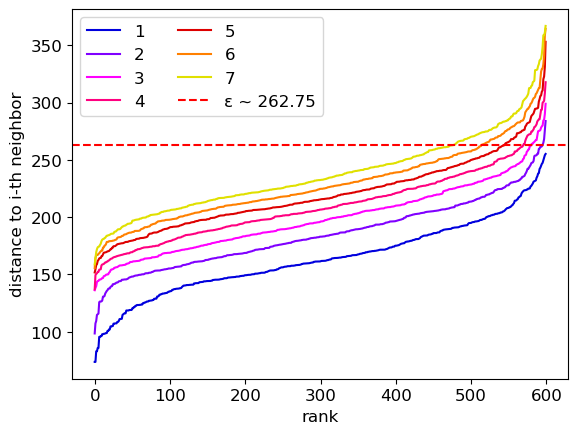

mean minimum distance between nn points:  163.65491354345073


In [5]:
nn = 7
# compute the distance to the nn nearest neighbors
nbrs = NearestNeighbors(n_neighbors=nn+1).fit(x) #, algorithm='ball_tree'
# distances and the indices of the nn nearest neighbors (10+1)
d, ind = nbrs.kneighbors(x) # returns distances and indices of nn neighbors

dd=d.T # distances to the i-th neighbor for all points, sorted by distance

k_distances = np.sort(dd[nn])
cut = int(0.8 * len(k_distances))
k_distances = k_distances[:cut]
l = range(len(k_distances))

knee = KneeLocator(l, k_distances, curve='convex', direction='increasing')
eps_estimate = k_distances[knee.knee]

# note: dd[0] has a trivial set of zeros
listc= ["#0000DD","#8000FF","#FF00FF","#FF0080","#DD0000",
        "#FF8000","#E0E000","#30D000","#00A030","#33A0A0"]
for i in range(1,nn+1):
    plt.plot(np.sort(dd[i]),c=listc[i-1],label=str(i))
    plt.xlabel("rank")
    plt.ylabel("distance to i-th neighbor")
plt.axhline(y=eps_estimate, color='red', linestyle='--', label=f"ε ~ {eps_estimate:.2f}")
plt.legend(ncol=2)
plt.show()
mean_min_dist = np.mean(dd[1]) # mean distance to the nearest neighbor
print("mean minimum distance between nn points: ",mean_min_dist)

The distance value that is larger than 80% of the other distances is used as epsilon for defining clusters. It is not too small and not too large:

If epsilon is too small: there would be too many clusters
If epsilon is too large → clustering becomes imprecise, merging points that are too far apart

This value roughly corresponds to the “knee” of the curve, where the distances start to separate dense neighbors from isolated points.

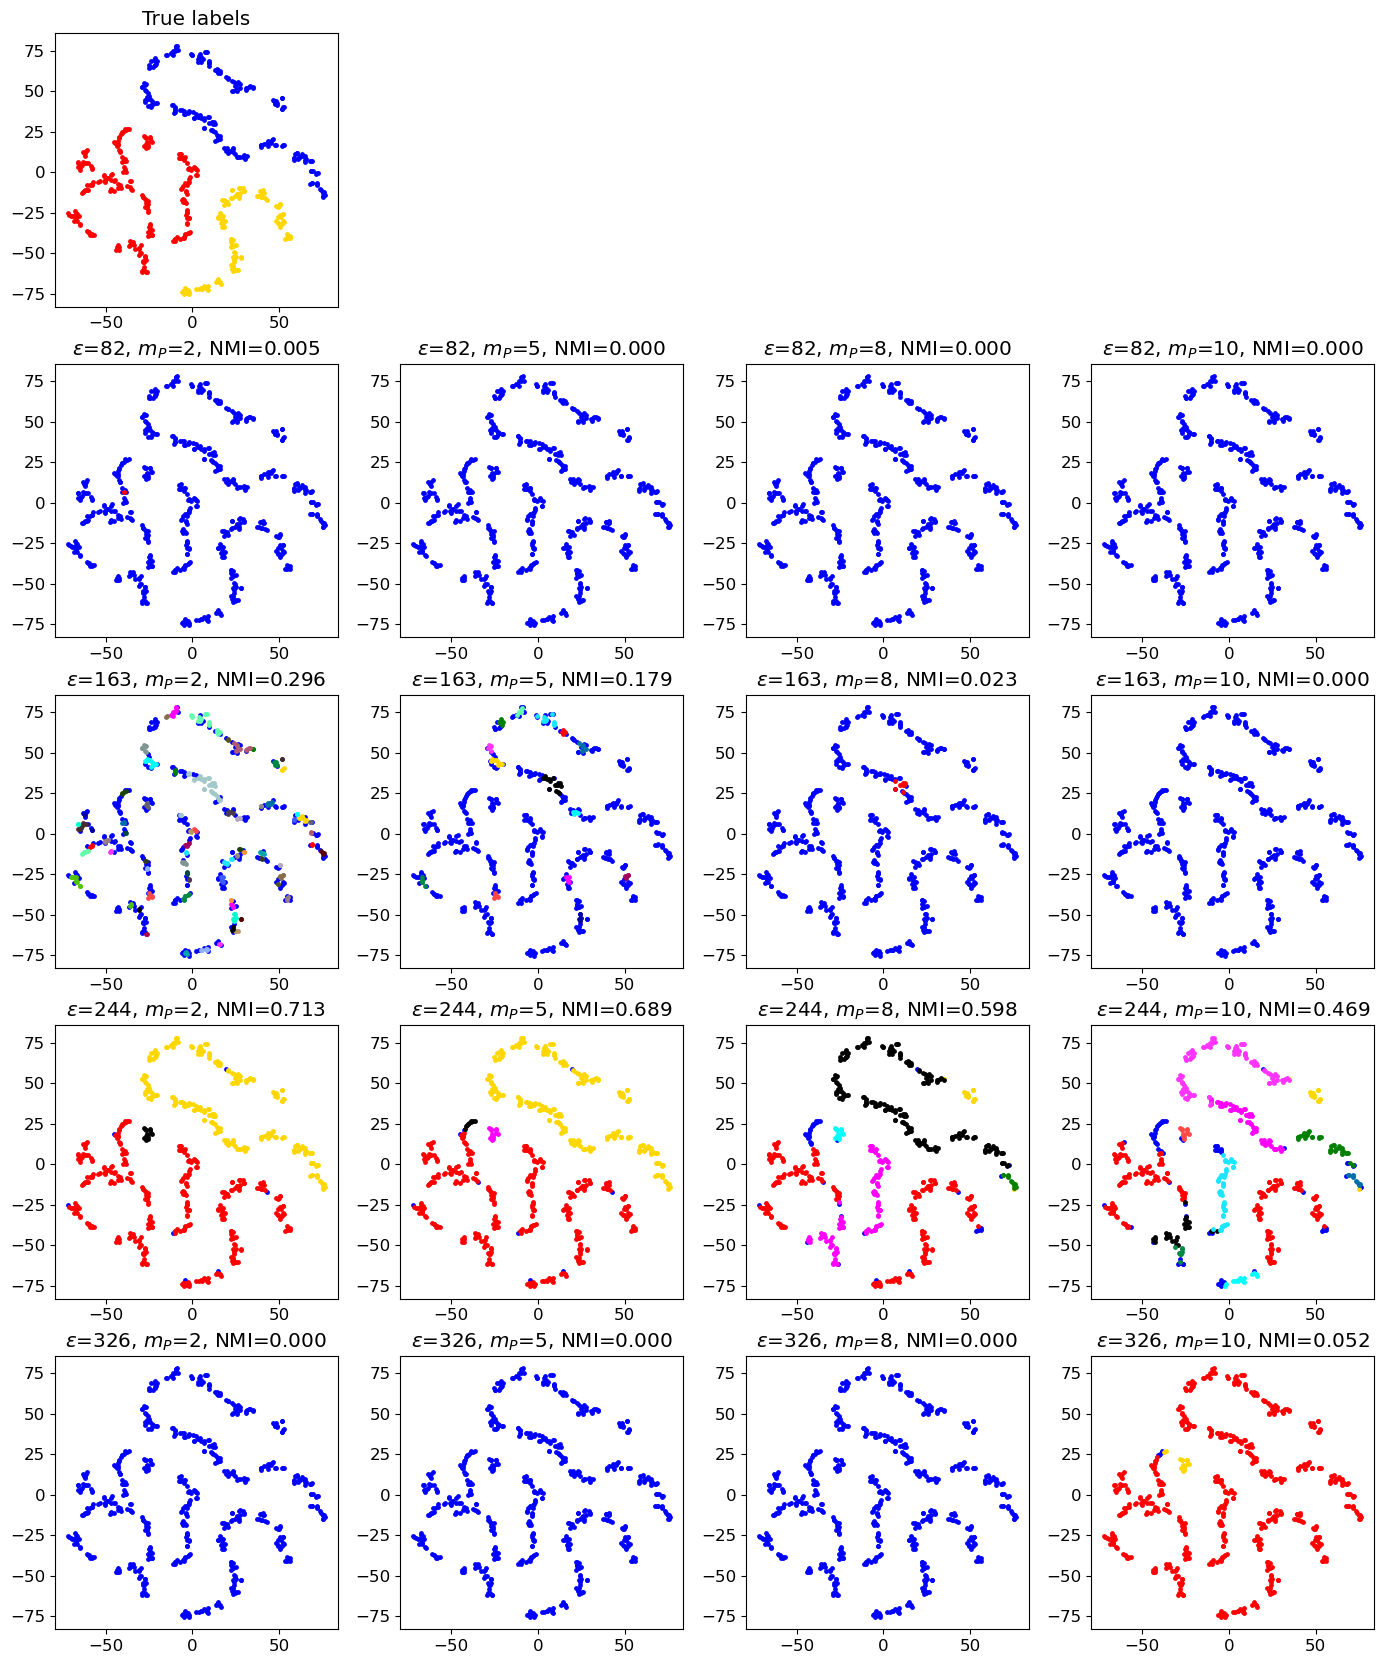

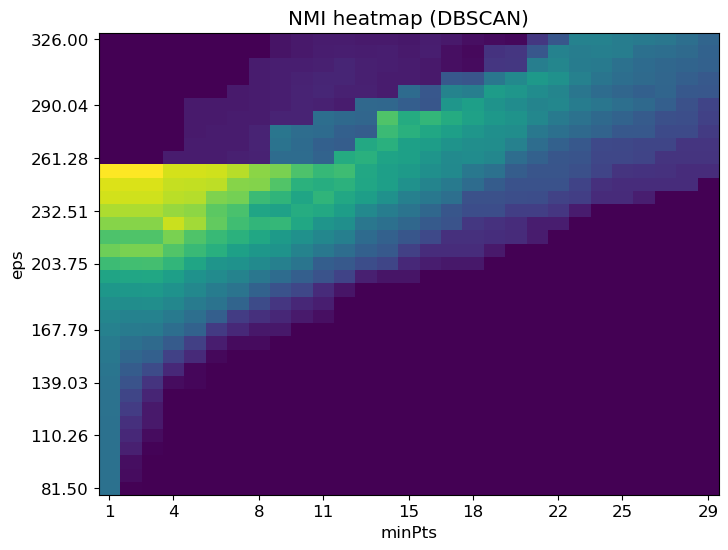

Best epsilon and minimum points:  254.08823529411765 1


In [6]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
cpalette = ["blue","red","gold","black","magenta","green","cyan","#1CE6FF", "#FF34FF", "#FF4A46","#008941", "#006FA6", "#A30059", "#0000A6", "#63FFAC","#B79762", "#004D43", "#8FB0FF", "#997D87","#5A0007", "#809693","#1B4400", "#4FC601", "#3B5DFF", "#4A3B53","#886F4C","#34362D", "#B4A8BD", "#00A6AA", "#452C2C","#636375", "#A3C8C9", "#FF913F", "#938A81","#575329", "#00FECF", "#B05B6F"]
from collections import OrderedDict
ms = 6

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

# Normalized mutual information function
# Note that this deals with the label permutation problem
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def plotting_ax(X, y, ax):
    # plotting function
    for i, yu in enumerate(np.unique(y)):
        pos = (y == yu)
        ax.scatter(X[pos,0], X[pos,1],c=cpalette[i%len(cpalette)],s=ms)

# DBSCAN has a few parameters, let's sweep over a few parameters and see what happens
np.random.seed(12345)
n_true_center=3 
#X, ytrue = make_blobs(10000, 2, n_true_center) # Generating random gaussian mixture
X2D = X_all[2] # best(?) visualization of the data in 2D, obtained by t-SNE with perplexity=8
X = data
y_true = y

#eps_range = [0.01,0.1,0.5,1.0,10.]
if mean_min_dist<10:
    r=mean_min_dist # mean minimum distance between nn points
else:
    r = int(mean_min_dist)
eps_range = [r/2,r,1.5*r,2*r] # range of eps values to try

min_sample_range = [2,5,8,10] 
DIMY=len(eps_range) 
DIMX=len(min_sample_range)
fig, ax = plt.subplots(DIMY+1,DIMX,figsize=(14,16.8))

i,j=0,0
nmi=1
plotting_ax(X2D,y,ax[i,j])
ax[i,j].set_title('True labels')

nmi_matrix = np.zeros((len(eps_range), len(min_sample_range)))
for j in range(1,DIMX): fig.delaxes(ax[i,j])
    
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        plotting_ax(X2D,y_hat,ax[i+1,j])
        nmi=NMI(y_hat, y_true)
        ax[i+1,j].set_title(r'$\epsilon$=%.0f, $m_P$=%i, NMI=%.3f'%(eps,min_samples,nmi))

eps_range = np.linspace(0.5*r, 2*r, 35)
min_sample_range = np.arange(1,30)
nmi_matrix = np.zeros((len(eps_range), len(min_sample_range)))
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_sample_range):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        model.fit(X)
        y_hat = model.labels_ # predicted labels
        nmi = NMI(y_hat, y_true)
        nmi_matrix[i, j] = nmi
    
plt.tight_layout(h_pad=0.5)
plt.show()
plt.figure(figsize=(8,6))

plt.imshow(nmi_matrix, origin='lower', aspect='auto')

plt.colorbar

plt.xticks(range(len(min_sample_range)), min_sample_range)
plt.yticks(range(len(eps_range)), [f"{e:.2f}" for e in eps_range])

plt.xlabel("minPts")
plt.ylabel("eps")
plt.title("NMI heatmap (DBSCAN)")
num_xticks = 9
num_yticks = 9

xtick_pos = np.linspace(0, len(min_sample_range)-1, num_xticks, dtype=int)
ytick_pos = np.linspace(0, len(eps_range)-1, num_yticks, dtype=int)

plt.xticks(xtick_pos, [min_sample_range[i] for i in xtick_pos])
plt.yticks(ytick_pos, [f"{eps_range[i]:.2f}" for i in ytick_pos])

plt.show()

max_idx = np.argmax(nmi_matrix)
max_pos = np.unravel_index(max_idx, nmi_matrix.shape)
eps_opt = eps_range[max_pos[0]]
min_sample_opt = min_sample_range[max_pos[1]]
print("Best epsilon and minimum points: ", eps_opt, min_sample_opt)

## Correlation from heatmap
There 's a positive correlation between epsilon and the minimum of points, we can notice that from a certain value of epsilon the value of the nmi drops significatly. 

## 2. Understanding the 12-dimensional data

Explained variance ratio with n=2 dimensions 0.8697080866745368
Explained variance ratio with n=3 dimensions 0.9628284852121716


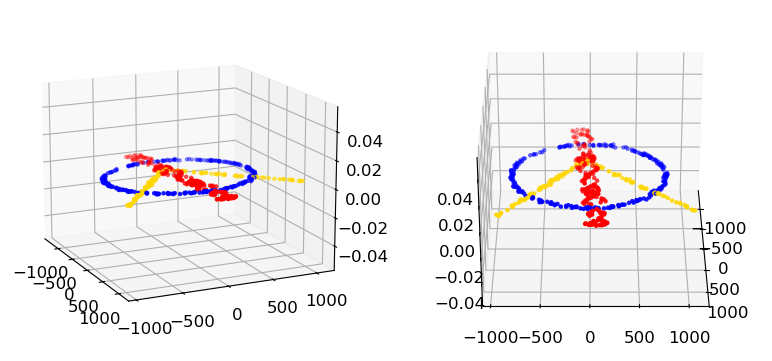

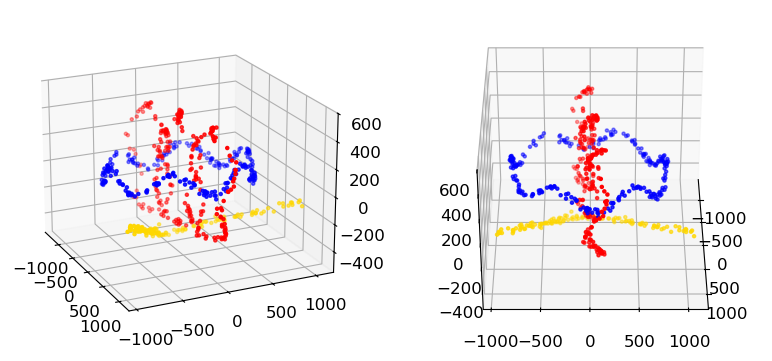

In [7]:
mycmap = ListedColormap(["blue","red","gold" ])

pca = PCA(n_components=2)

x_pca = pca.fit_transform(x)
print("Explained variance ratio with n=2 dimensions", np.sum(pca.explained_variance_ratio_))

fig = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x_pca[:,0], x_pca[:,1], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(15+15*i, 25*(i-1))
    
plt.draw()

pca_ = PCA(n_components=3)

x_pca_ = pca_.fit_transform(x)
print("Explained variance ratio with n=3 dimensions", np.sum(pca_.explained_variance_ratio_))

fig_ = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig_.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x_pca_[:,0], x_pca_[:,1], x_pca_[:,2], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(20+15*i, 25*(i-1))
    
plt.draw()

Principal component analysis (PCA) helps understand the data structure, as keeping only the 3 principal components we can explain around 96% of the dataset's total variability. 

## 5. Visualize data

/home/francesco/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/francesco/anaconda3/lib/python3.13/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Text(0.5, 1.0, 'Isomap')

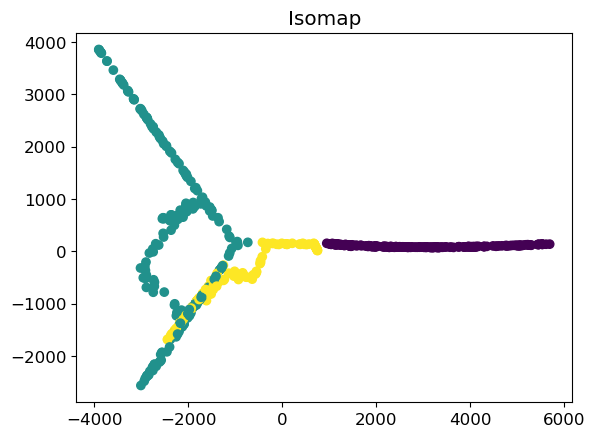

In [8]:
from sklearn.manifold import Isomap

iso = Isomap(n_components=2)
X_iso = iso.fit_transform(X)

plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y)
plt.title("Isomap")

Text(0.5, 1.0, 'LLE')

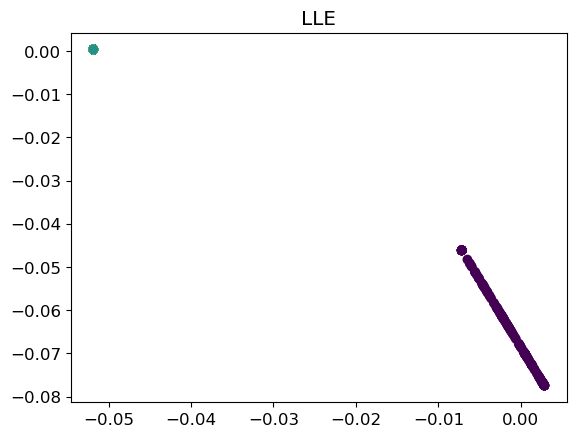

In [9]:
from sklearn.manifold import LocallyLinearEmbedding

lle = LocallyLinearEmbedding(n_components=2)
X_lle = lle.fit_transform(X)

plt.scatter(X_lle[:, 0], X_lle[:, 1], c=y)
plt.title("LLE")

/home/francesco/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/francesco/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Text(0.5, 1.0, 'MDS')

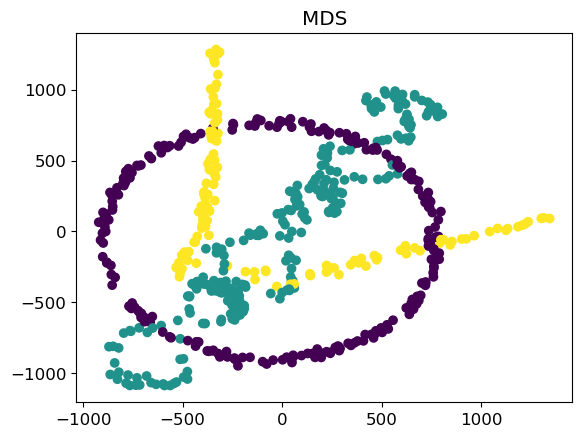

In [10]:
from sklearn.manifold import MDS

mds = MDS(n_components=2)
X_mds = mds.fit_transform(X)

plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y)
plt.title("MDS")

Text(0.5, 1.0, 'Spectral Embedding')

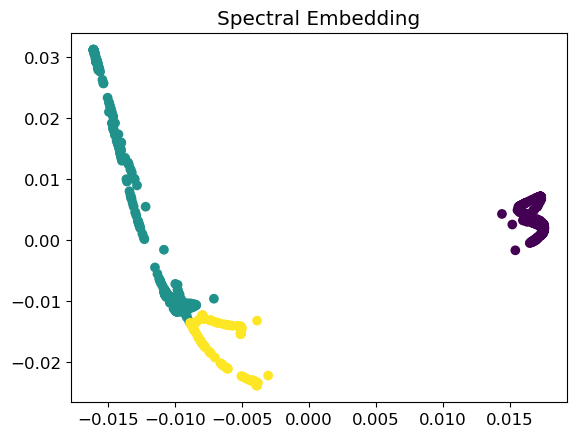

In [11]:
from sklearn.manifold import SpectralEmbedding

se = SpectralEmbedding(n_components=2, n_neighbors=10)
X_se = se.fit_transform(X)

plt.scatter(X_se[:, 0], X_se[:, 1], c=y, cmap='viridis')
plt.title("Spectral Embedding")

## 3. Confrontation with k-means

NMI k-means: 0.125
NMI DBSCAN: 0.764


Text(0.5, 1.0, 'Ground truth')

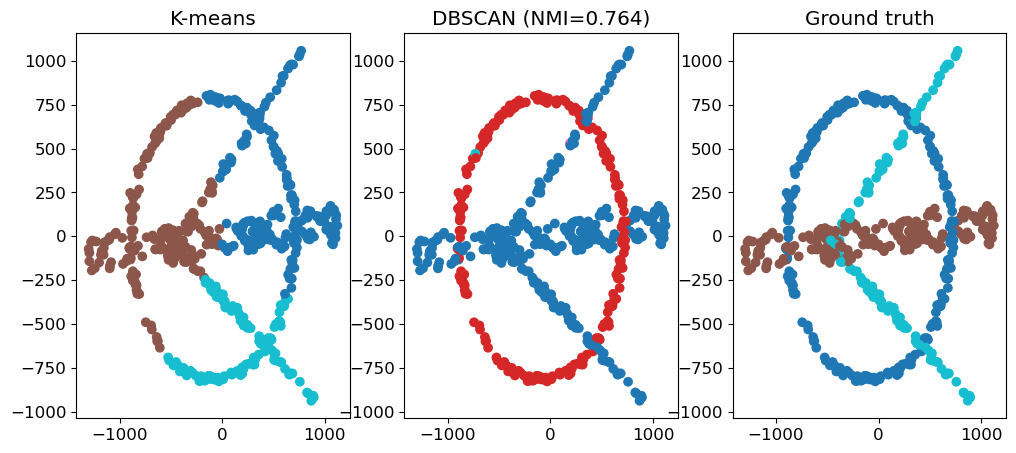

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score

# scaled data
x_scaled = StandardScaler().fit_transform(x)

# kmeans valuation
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(x_scaled)

nmi_km = normalized_mutual_info_score(y, labels_km)
print(f"NMI k-means: {nmi_km:.3f}")

# dbscan optimized
labels_dbscan = DBSCAN(eps=eps_opt, min_samples=min_sample_opt).fit_predict(X)
nmi_dbscan = normalized_mutual_info_score(y, labels_dbscan)
print(f"NMI DBSCAN: {nmi_dbscan:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12,5))
plt.title("Comparison with 2 dimnesions")
axes[0].scatter(x_pca[:,0], x_pca[:,1], c=labels_km, cmap='tab10')
axes[0].set_title("K-means")
axes[1].scatter(x_pca[:,0], x_pca[:,1], c=labels_dbscan, cmap='tab10')
axes[1].set_title(f"DBSCAN (NMI={nmi_dbscan:.3f})")
axes[2].scatter(x_pca[:,0], x_pca[:,1], c=y, cmap='tab10')
axes[2].set_title("Ground truth")


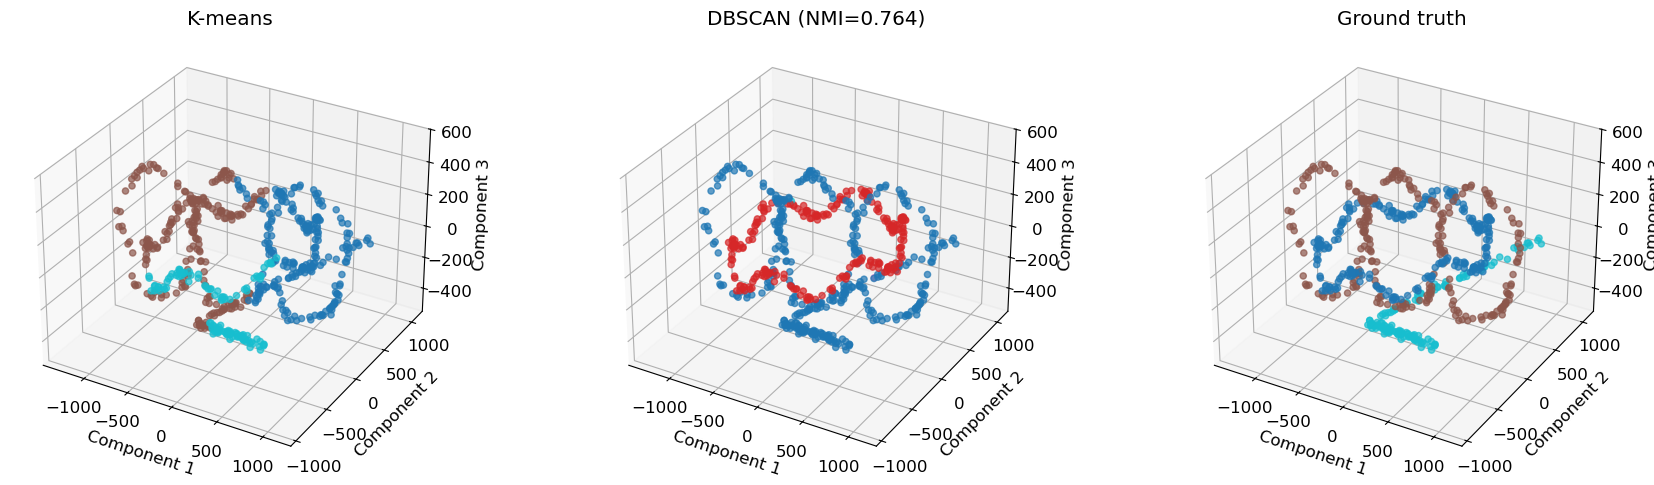

In [22]:
fig = plt.figure(figsize=(18, 5))

titles = ["K-means", f"DBSCAN (NMI={nmi_dbscan:.3f})", "Ground truth"]
labels_list = [labels_km, labels_dbscan, y]

for i, (title, labels) in enumerate(zip(titles, labels_list)):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.scatter(x_pca_[:,0], x_pca_[:,1], x_pca_[:,2],
               c=labels, cmap='tab10', s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")

plt.tight_layout()
plt.show()

The comparison between k-means and the ground truth is bad, since the points are grouped in an almost spherical cluster, and `NMI_k-means = 0.125`, while DBSCAN has a pretty good `NMI_DBSCAN = 0.764`.